# Speciation Engine Protocol Hierarchy

PyOMES exposes a graduated protocol hierarchy for speciation engines, ranging
from a simple black-box `solve()` interface to a full white-box that exposes
residuals and analytical Jacobians.  Each level unlocks additional capabilities
without breaking the contract of the level below.

| Level | Protocol | Methods beyond base | Implementations |
|---|---|---|---|
| **Black box** | `ChemicalEquilibriumEngineProtocol` | `solve`, `algebraic_species`, `reset_cache`, `reset_counters`, `n_solve_calls` | `BisectionChemicalEquilibriumEngine`, `NRChemicalEquilibriumEngine` |
| **Gray box** | `GrayBoxEngineProtocol` | `jacobian_dz_dy(**kwargs)` — ∂z/∂y | `NRChemicalEquilibriumEngine` (all), `NumericalGradientEquilibriumEngine`, `PHREEQCChemicalEquilibriumEngine` |
| **White box** | `WhiteBoxEngineProtocol` | `residual(**kwargs)`, `jacobian_dg_dz(**kwargs)`, `jacobian_dg_dy(**kwargs)` | `NRChemicalEquilibriumEngine(retain_jacobian=True)` |

This notebook shows how to construct each engine type, use `isinstance()` to
discover capabilities at runtime, and call the gray- and white-box methods
that unlock analytical Jacobians for implicit ODE solvers.

**Sections**
1. Black-box baseline — both engines solve the same chemistry
2. Protocol `isinstance` checks
3. Gray-box — `jacobian_dz_dy()` from `NumericalGradientEquilibriumEngine`
4. White-box — `NRChemicalEquilibriumEngine(retain_jacobian=True)` residual and split Jacobians
5. White-box `jacobian_dz_dy()` — visualising ∂z/∂y
6. `SimultaneousAdaptiveSolver` integration — `use_engine_jacobian=True`
7. `PHREEQCChemicalEquilibriumEngine` — external solver (skipped if `phreeqpython` absent)

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import warnings

def _find_repo():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise RuntimeError("Run from inside the PyOMES repo")

sys.path.insert(0, str(_find_repo() / "models"))

from PyOMES.chemistry.common_species import (
    H2O, H_plus, OH_minus,
    CO2, HCO3_minus, CO3_2minus,
    NH3, NH4_plus,
)
from PyOMES.reactions.equilibrium import EquilibriumReaction
from PyOMES.reactions.stoichiometry import StoichiometryEntry
from PyOMES.chemical_equilibrium.engine import BisectionChemicalEquilibriumEngine
from PyOMES.chemical_equilibrium.nr_engine import NRChemicalEquilibriumEngine
from PyOMES.chemical_equilibrium.numerical_gradient import NumericalGradientEquilibriumEngine
from PyOMES.chemical_equilibrium.protocols import (
    ChemicalEquilibriumEngineProtocol,
    GrayBoxEngineProtocol,
    WhiteBoxEngineProtocol,
)

def _e(sp, coeff):
    return StoichiometryEntry(species=sp, phase="liquid", coefficient=coeff)

# Carbonate + ammonia reactions (AD core chemistry)
water = EquilibriumReaction(
    stoichiometry=[_e(H2O, -1), _e(H_plus, +1), _e(OH_minus, +1)],
    log_K=-14.0, label="water",
)
co2_first = EquilibriumReaction(
    stoichiometry=[_e(CO2, -1), _e(H2O, -1), _e(HCO3_minus, +1), _e(H_plus, +1)],
    log_K=-6.35, total_id="CO2", label="co2_first",
)
co2_second = EquilibriumReaction(
    stoichiometry=[_e(HCO3_minus, -1), _e(CO3_2minus, +1), _e(H_plus, +1)],
    log_K=-10.33, total_id="CO2", label="co2_second",
)
nh4 = EquilibriumReaction(
    stoichiometry=[_e(NH4_plus, -1), _e(NH3, +1), _e(H_plus, +1)],
    log_K=-9.25, total_id="NH3", label="nh4",
)
reactions = [water, co2_first, co2_second, nh4]

TOTALS   = {"CO2": 0.05, "NH3": 0.04}   # mol/L — representative AD digestate
SI       = {}                             # no strong ions

print("Imports OK")

Imports OK


## 1  Black-box baseline

Both `BisectionChemicalEquilibriumEngine` (1-D charge-balance bisection) and `NRChemicalEquilibriumEngine`
(Newton-Raphson in log-activity space) implement `ChemicalEquilibriumEngineProtocol` and
accept the same `solve(totals=..., strong_ions=...)` call.

The solve output is a plain `dict` — protocol-neutral, so downstream code
doesn't need to know which engine produced it.

In [2]:
cb_engine = BisectionChemicalEquilibriumEngine.from_reactions(reactions)
nr_engine  = NRChemicalEquilibriumEngine.from_reactions(reactions)

out_cb = cb_engine.solve(CT_TIC=TOTALS["CO2"], CT_NH_T=TOTALS["NH3"])
out_nr = nr_engine.solve(totals=TOTALS, strong_ions=SI)

def _get(result, key):
    return result.pH if key == "pH" else result.species_mol_L.get(key, float("nan"))

print(f"{'Species':<12} {'ChargeBalance':>15} {'NR engine':>12} {'difference':>12}")
print("-" * 54)
species_to_show = ["pH", "H+", "OH-", "CO2", "HCO3-", "CO3--", "NH3", "NH4+"]
for sp in species_to_show:
    v_cb = _get(out_cb, sp)
    v_nr = _get(out_nr, sp)
    diff = v_nr - v_cb if not (v_cb != v_cb or v_nr != v_nr) else float("nan")
    print(f"{sp:<12} {v_cb:>15.6g} {v_nr:>12.6g} {diff:>12.2e}")

Species        ChargeBalance    NR engine   difference
------------------------------------------------------
pH                    6.9405       6.9405    -2.48e-13
H+               1.14684e-07  1.14684e-07     6.54e-20
OH-              8.71962e-08  8.71962e-08    -4.97e-20
CO2                0.0102114    0.0102114     4.64e-15
HCO3-              0.0397724    0.0397724    -4.61e-15
CO3--            1.62211e-05  1.62211e-05    -1.11e-17
NH3              0.000195179  0.000195179     3.93e-13
NH4+               0.0398048    0.0398048     8.02e-11


## 2  Protocol `isinstance` checks

The protocols are `@runtime_checkable`, so `isinstance()` works without
subclassing.  The check is purely structural (method names) — not based on
class hierarchy or flags.

In [3]:
engines = {
    "BisectionChemicalEquilibriumEngine (CB)": cb_engine,
    "NRChemicalEquilibriumEngine (default)": nr_engine,
    "NumericalGradientEquilibriumEngine(NR)": NumericalGradientEquilibriumEngine(NRChemicalEquilibriumEngine.from_reactions(reactions)),
    "NRChemicalEquilibriumEngine(retain_jacobian=True)": NRChemicalEquilibriumEngine.from_reactions(reactions, retain_jacobian=True),
}

protocols = [
    ("ChemicalEquilibriumEngineProtocol", ChemicalEquilibriumEngineProtocol),
    ("GrayBoxEngineProtocol",    GrayBoxEngineProtocol),
    ("WhiteBoxEngineProtocol",   WhiteBoxEngineProtocol),
]

header = f"{'Engine':<46}" + "".join(f"{name[-15:]:>17}" for name, _ in protocols)
print(header)
print("-" * (46 + 17 * len(protocols)))
for eng_name, eng in engines.items():
    row = f"{eng_name:<46}"
    for _, proto in protocols:
        tick = "✓" if isinstance(eng, proto) else "·"
        row += f"{tick:>17}"
    print(row)

print()
print("Note: NRChemicalEquilibriumEngine satisfies WhiteBoxEngineProtocol structurally")
print("(all methods exist) regardless of retain_jacobian.  The split-Jacobian")
print("methods raise RuntimeError unless retain_jacobian=True was passed at")
print("construction — see §4 for the white-box usage pattern.")

Engine                                          mEngineProtocol  xEngineProtocol  xEngineProtocol
-------------------------------------------------------------------------------------------------
BisectionChemicalEquilibriumEngine (CB)                       ✓                ·                ·
NRChemicalEquilibriumEngine (default)                         ✓                ✓                ✓
NumericalGradientEquilibriumEngine(NR)                        ✓                ✓                ·
NRChemicalEquilibriumEngine(retain_jacobian=True)                ✓                ✓                ✓

Note: NRChemicalEquilibriumEngine satisfies WhiteBoxEngineProtocol structurally
(all methods exist) regardless of retain_jacobian.  The split-Jacobian
methods raise RuntimeError unless retain_jacobian=True was passed at
construction — see §4 for the white-box usage pattern.


## 3  Gray-box — `NumericalGradientEquilibriumEngine`

`NumericalGradientEquilibriumEngine` wraps any engine that accepts `totals=` in `solve()`
and promotes it to `GrayBoxEngineProtocol` by computing `jacobian_dz_dy()` via
central finite differences.

> **Note:** `BisectionChemicalEquilibriumEngine` (charge-balance bisection) uses the legacy
> `CT_TIC=` / `CT_NH_T=` kwarg style and does **not** accept `totals=`, so it
> cannot be wrapped by `NumericalGradientEquilibriumEngine`.  Use `NRChemicalEquilibriumEngine`
> as the inner engine; it accepts `totals=` natively.

`jacobian_dz_dy()` returns a `SpeciationJacobian` dataclass:

```python
@dataclass(frozen=True)
class SpeciationJacobian:
    dz_dy: np.ndarray          # shape (n_alg, n_comp)
    algebraic_ids: tuple[str]  # row labels
    component_ids: tuple[str]  # column labels
```

Each entry `dz_dy[i, j]` = ∂c_i/∂C_j (mol/L per mol/L) — how the concentration
of algebraic species `i` changes when component total `j` is perturbed.

Useful for:
- Sensitivity analysis (which species respond most to a CO₂ change?)
- Jacobian supply to implicit ODE solvers (see §6)
- Gradient-based parameter estimation

In [4]:
# Wrap NRChemicalEquilibriumEngine — NumericalGradientEquilibriumEngine requires totals= support,
# which NRChemicalEquilibriumEngine provides natively (BisectionChemicalEquilibriumEngine does not).
nr_for_grad = NRChemicalEquilibriumEngine.from_reactions(reactions)
num_grad_engine = NumericalGradientEquilibriumEngine(nr_for_grad)
print("is GrayBox:", isinstance(num_grad_engine, GrayBoxEngineProtocol))
print("inner engine type:", type(num_grad_engine._engine).__name__)
print("n_solve_calls before jacobian:", nr_for_grad.n_solve_calls)

# One jacobian_dz_dy() call uses 2*n_comp inner solve() calls
jac_ng = num_grad_engine.jacobian_dz_dy(totals=TOTALS, strong_ions=SI)
print(f"n_solve_calls after jacobian:  {nr_for_grad.n_solve_calls}  "
      f"(2 × {len(jac_ng.component_ids)} components)")
print(f"\njac shape:     {jac_ng.dz_dy.shape}  (n_alg={len(jac_ng.algebraic_ids)}, n_comp={len(jac_ng.component_ids)})")
print(f"algebraic_ids: {jac_ng.algebraic_ids}")
print(f"component_ids: {jac_ng.component_ids}")

is GrayBox: True
inner engine type: NRChemicalEquilibriumEngine
n_solve_calls before jacobian: 0
n_solve_calls after jacobian:  4  (2 × 2 components)

jac shape:     (8, 2)  (n_alg=8, n_comp=2)
algebraic_ids: ('CO2', 'CO3--', 'H+', 'H2O', 'HCO3-', 'NH3', 'NH4+', 'OH-')
component_ids: ('CO2', 'NH3')


In [5]:
# Print the Jacobian as a readable table
print(f"\n∂z/∂y  (mol/L per mol/L)  from NumericalGradientEquilibriumEngine")
print(f"{'Species':<12}" + "".join(f"{'∂/∂' + c:>14}" for c in jac_ng.component_ids))
print("-" * (12 + 14 * len(jac_ng.component_ids)))
for i, sp in enumerate(jac_ng.algebraic_ids):
    row = f"{sp:<12}" + "".join(f"{jac_ng.dz_dy[i, j]:>14.4f}" for j in range(len(jac_ng.component_ids)))
    print(row)

print("\nInterpretation:")
print("  ∂[H+]/∂[CO2] > 0 : adding CO2 increases H+ (lowers pH)")
print("  ∂[HCO3-]/∂[CO2] > 0 : adding CO2 increases bicarbonate")
print("  ∂[NH4+]/∂[NH3] > 0 : adding total-N increases ammonium")
print("  ∂[H+]/∂[NH3]  < 0 : adding NH3 consumes H+ (raises pH)")


∂z/∂y  (mol/L per mol/L)  from NumericalGradientEquilibriumEngine
Species             ∂/∂CO2        ∂/∂NH3
----------------------------------------
CO2                 0.9799       -0.9696
CO3--              -0.0015        0.0023
H+                  0.0000       -0.0000
H2O                 0.0000        0.0000
HCO3-               0.0216        0.9673
NH3                -0.0185        0.0280
NH4+                0.0186        0.9719
OH-                -0.0000        0.0000

Interpretation:
  ∂[H+]/∂[CO2] > 0 : adding CO2 increases H+ (lowers pH)
  ∂[HCO3-]/∂[CO2] > 0 : adding CO2 increases bicarbonate
  ∂[NH4+]/∂[NH3] > 0 : adding total-N increases ammonium
  ∂[H+]/∂[NH3]  < 0 : adding NH3 consumes H+ (raises pH)


## 4  White-box — residual and split Jacobians

`NRChemicalEquilibriumEngine(retain_jacobian=True)` retains the NR Jacobian matrix
after each solve and exposes three additional methods:

| Method | Returns | Shape | Meaning |
|---|---|---|---|
| `residual(**kwargs)` | `np.ndarray` | (m,) | Residual vector g(y, x) without updating state |
| `jacobian_dg_dz(**kwargs)` | `SparseJacobian` | (m, m) | ∂g/∂z — the NR Jacobian in log-activity space |
| `jacobian_dg_dy(**kwargs)` | `SparseJacobian` | (m, m−1) | ∂g/∂y — selection matrix (mass-balance rows) |

where m = number of master species (= number of components + 1 for H⁺).

These are used by the Implicit Function Theorem (IFT) to derive `jacobian_dz_dy()`
without finite differences.

In [6]:
wb_engine = NRChemicalEquilibriumEngine.from_reactions(reactions, retain_jacobian=True)
print("is WhiteBox:", isinstance(wb_engine, WhiteBoxEngineProtocol))

# Must solve first to populate the cache
out_wb = wb_engine.solve(totals=TOTALS, strong_ions=SI)
print(f"pH after solve: {out_wb.pH:.4f}")
print(f"n_solve_calls:  {wb_engine.n_solve_calls}")

is WhiteBox: True
pH after solve: 6.9405
n_solve_calls:  1


In [7]:
# residual() evaluates g(y, x) without modifying state
# At the solution it should be near machine precision
R_at_solution = wb_engine.residual(totals=TOTALS, strong_ions=SI)
print("Residual at solution (should be ≈ 0):")
for i, master in enumerate(wb_engine._tableau.masters):
    print(f"  g[{master}] = {R_at_solution[i]:.2e}")

# At a perturbed state (wrong totals) the residual is non-zero
totals_perturbed = {"CO2": TOTALS["CO2"] * 1.5, "NH3": TOTALS["NH3"]}
R_perturbed = wb_engine.residual(totals=totals_perturbed, strong_ions=SI)
print("\nResidual at perturbed totals (CT_CO2 × 1.5):")
for i, master in enumerate(wb_engine._tableau.masters):
    print(f"  g[{master}] = {R_perturbed[i]:.4f}")

Residual at solution (should be ≈ 0):
  g[H+] = 1.39e-17
  g[CO2] = 8.06e-11
  g[NH3] = 8.02e-11

Residual at perturbed totals (CT_CO2 × 1.5):
  g[H+] = -0.0250
  g[CO2] = 0.0000
  g[NH3] = 0.0000


In [8]:
# jacobian_dg_dz: the NR Jacobian in log-activity space
# Shape (m, m): rows = residual equations, columns = log-activity variables
dg_dz = wb_engine.jacobian_dg_dz()
print("jacobian_dg_dz — NR Jacobian in log-activity space")
print(f"  shape:   {dg_dz.matrix.shape}")
print(f"  row_ids: {dg_dz.row_ids}")
print(f"  col_ids: {dg_dz.col_ids}")
print(f"  format:  {dg_dz.matrix.format} (sparse)")
print("\nDense form:")
print(np.array(dg_dz.matrix.todense()).round(3))

# jacobian_dg_dy: structural selection matrix — top block is -I (mass-balance rows)
# bottom row is zeros (charge balance doesn't directly depend on component totals)
dg_dy = wb_engine.jacobian_dg_dy()
print("\njacobians_dg_dy — selection matrix")
print(f"  shape:   {dg_dy.matrix.shape}  (m × (m-1): last row is charge-balance, has no direct y)")
print("\nDense form:")
print(np.array(dg_dy.matrix.todense()).round(3))

jacobian_dg_dz — NR Jacobian in log-activity space
  shape:   (3, 3)
  row_ids: ('CO2', 'NH3', 'H+')
  col_ids: ('H+', 'CO2', 'NH3')
  format:  csr (sparse)

Dense form:
[[-0.092  0.115  0.   ]
 [ 0.092  0.     0.092]
 [ 0.183 -0.092  0.092]]

jacobians_dg_dy — selection matrix
  shape:   (3, 2)  (m × (m-1): last row is charge-balance, has no direct y)

Dense form:
[[-1.  0.]
 [ 0. -1.]
 [ 0.  0.]]


## 5  White-box `jacobian_dz_dy()` — visualising ∂z/∂y

`jacobian_dz_dy()` applies the Implicit Function Theorem to convert the
split Jacobians into the total sensitivity ∂z/∂y:

$$\frac{\partial \mathbf{x}}{\partial \mathbf{y}} = -(\partial_z g)^{-1} \partial_y g
\quad \Rightarrow \quad
\frac{\partial c_j}{\partial C_i} = \ln 10 \sum_k \nu_{jk}\, c_j\, \frac{\partial x_k}{\partial C_i}$$

where **x** are the log-activities of master species.

Unlike `NumericalGradientEquilibriumEngine`, this path is O(m³) (a single matrix solve)
rather than O(m × n_solve) (2 solves per component).  For the NR engine
with `retain_jacobian=True` the matrix is already in cache — the extra cost
is just the linear solve.

In [9]:
# jacobian_dz_dy uses cached NR Jacobian (no extra solve calls)
n_before = wb_engine.n_solve_calls
jac_wb = wb_engine.jacobian_dz_dy()   # no extra solve
n_after = wb_engine.n_solve_calls
print(f"Extra solve calls for jacobian_dz_dy(): {n_after - n_before}  (vs 2×n_comp for NumericalGradientEquilibriumEngine)")

print(f"\n∂z/∂y  (mol/L per mol/L)  from white-box IFT")
print(f"{'Species':<12}" + "".join(f"{'∂/∂' + c:>14}" for c in jac_wb.component_ids))
print("-" * (12 + 14 * len(jac_wb.component_ids)))
for i, sp in enumerate(jac_wb.algebraic_ids):
    row = f"{sp:<12}" + "".join(f"{jac_wb.dz_dy[i, j]:>14.4f}" for j in range(len(jac_wb.component_ids)))
    print(row)

Extra solve calls for jacobian_dz_dy(): 0  (vs 2×n_comp for NumericalGradientEquilibriumEngine)

∂z/∂y  (mol/L per mol/L)  from white-box IFT
Species             ∂/∂CO2        ∂/∂NH3
----------------------------------------
CO2                 0.9799       -0.9696
CO3--              -0.0015        0.0023
H+                  0.0000       -0.0000
H2O                 0.0000        0.0000
HCO3-               0.0216        0.9673
NH3                -0.0185        0.0280
NH4+                0.0185        0.9720
OH-                -0.0000        0.0000


In [10]:
# Compare white-box (analytical IFT) vs NumericalGradientEquilibriumEngine (FD)
# They should agree to within FD accuracy (eps ≈ 1e-5 * C_j)
num_wrapper = NumericalGradientEquilibriumEngine(wb_engine)
jac_fd = num_wrapper.jacobian_dz_dy(totals=TOTALS, strong_ions=SI)

print("Comparison: analytical IFT vs finite differences")
print(f"{'Species':<12}" + "".join(f"{'IFT ∂/∂' + c:>15} {'FD ∂/∂' + c:>12} {'rel err':>9}" for c in jac_wb.component_ids))
print("-" * (12 + 36 * len(jac_wb.component_ids)))
for i, sp in enumerate(jac_wb.algebraic_ids):
    # Need matching index in FD result (same algebraic_ids ordering)
    i_fd = jac_fd.algebraic_ids.index(sp)
    row = f"{sp:<12}"
    for j, comp in enumerate(jac_wb.component_ids):
        j_fd = jac_fd.component_ids.index(comp)
        v_ift = jac_wb.dz_dy[i, j]
        v_fd  = jac_fd.dz_dy[i_fd, j_fd]
        denom = max(abs(v_ift), 1e-12)
        rel   = abs(v_ift - v_fd) / denom
        row += f"{v_ift:>15.5f} {v_fd:>12.5f} {rel:>9.1e}"
    print(row)

Comparison: analytical IFT vs finite differences
Species          IFT ∂/∂CO2    FD ∂/∂CO2   rel err     IFT ∂/∂NH3    FD ∂/∂NH3   rel err
------------------------------------------------------------------------------------
CO2                 0.97991      0.97988   3.5e-05       -0.96960     -0.96964   3.5e-05
CO3--              -0.00154     -0.00154   3.4e-05        0.00233      0.00233   2.0e-05
H+                  0.00001      0.00001   3.4e-05       -0.00001     -0.00001   2.6e-05
H2O                 0.00000      0.00000   0.0e+00        0.00000      0.00000   0.0e+00
HCO3-               0.02163      0.02163   7.0e-05        0.96727      0.96726   9.8e-06
NH3                -0.01853     -0.01853   3.4e-05        0.02805      0.02805   2.0e-05
NH4+                0.01853      0.01853   7.0e-05        0.97195      0.97195   9.4e-06
OH-                -0.00001     -0.00001   3.4e-05        0.00001      0.00001   2.6e-05


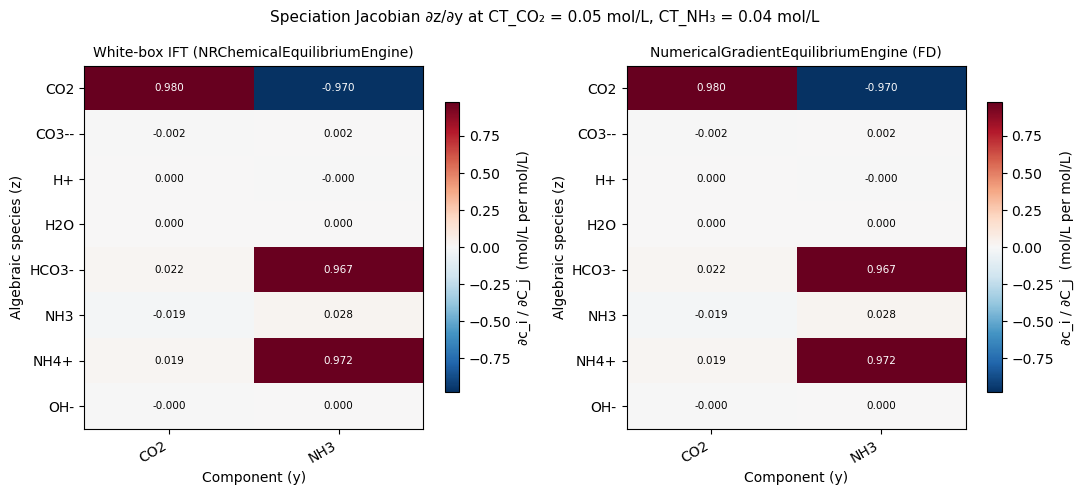

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, jac, title in [
    (axes[0], jac_wb, "White-box IFT (NRChemicalEquilibriumEngine)"),
    (axes[1], jac_fd, "NumericalGradientEquilibriumEngine (FD)"),
]:
    data = jac.dz_dy
    # Use symmetric log colour scale to handle sign differences
    vmax = np.abs(data).max()
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(jac.component_ids)))
    ax.set_xticklabels(jac.component_ids, rotation=30, ha="right")
    ax.set_yticks(range(len(jac.algebraic_ids)))
    ax.set_yticklabels(jac.algebraic_ids)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Component (y)")
    ax.set_ylabel("Algebraic species (z)")
    plt.colorbar(im, ax=ax, label="∂c_i / ∂C_j  (mol/L per mol/L)", shrink=0.8)
    # Annotate cells with values
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            ax.text(j, i, f"{data[i,j]:.3f}", ha="center", va="center",
                    fontsize=7.5, color="white" if abs(data[i,j]) > 0.3*vmax else "black")

plt.suptitle("Speciation Jacobian ∂z/∂y at CT_CO₂ = 0.05 mol/L, CT_NH₃ = 0.04 mol/L",
             fontsize=11)
plt.tight_layout()
plt.show()

## 6  `SimultaneousAdaptiveSolver` — `use_engine_jacobian=True`

When `SimultaneousAdaptiveSolver` is given an implicit method (BDF, Radau, LSODA) and the
CV's reaction system has a `GrayBoxEngineProtocol` engine, passing
`use_engine_jacobian=True` supplies an analytical Jacobian to `solve_ivp`.

For each liquid-component column of the ODE Jacobian, `jacobian_dz_dy()` is
used to predict the secondary algebraic species analytically, avoiding a full
speciation re-solve.  This saves `n_comp` speciation solver calls per Jacobian
evaluation.  Gas and non-component liquid columns fall back to forward
finite differences.

Without the flag a `UserWarning` is emitted to remind the user the Jacobian
is available.

In [12]:
from PyOMES.core import ControlVolume, GasPhase, LiquidPhase
from PyOMES.reactions import ReactionSystem
from PyOMES.core.solvers import SimultaneousAdaptiveSolver

gas = GasPhase(n_mol={"CO2": 0.01, "N2": 0.5}, V_L=0.4, T_K=308.15)
liq = LiquidPhase(n_mol={"CO2": 0.005, "NH3": 0.04}, V_L=1.6, T_K=308.15)

# Build a ReactionSystem backed by an NR engine with retain_jacobian=True
rxn_system = ReactionSystem(reactions, solver="newton_raphson")
nr_wb_for_cv = NRChemicalEquilibriumEngine.from_reactions(reactions, retain_jacobian=True)
rxn_system.attach_engine(nr_wb_for_cv)

cv = ControlVolume(
    phases={"gas": gas, "liquid": liq},
    reaction_system=rxn_system,
)
print("CV ready.  Engine type:", type(cv.reaction_system.engine).__name__)
print("Engine is GrayBox:", isinstance(cv.reaction_system.engine, GrayBoxEngineProtocol))
print("Engine is WhiteBox:", isinstance(cv.reaction_system.engine, WhiteBoxEngineProtocol))

CV ready.  Engine type: NRChemicalEquilibriumEngine
Engine is GrayBox: True
Engine is WhiteBox: True


In [13]:
# Without use_engine_jacobian=True, a UserWarning is emitted once per solve_step()
solver_default = SimultaneousAdaptiveSolver(method="BDF")
print(repr(solver_default))
print()

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    solver_default.solve_step(cv, dt_h=0.01, t_h=0.0)

for w in caught:
    if issubclass(w.category, UserWarning) and "GrayBoxEngineProtocol" in str(w.message):
        print(f"UserWarning: {w.message}")

SimultaneousAdaptiveSolver(method='BDF', rtol=1e-06, atol=1e-09, max_step=1.0, use_engine_jacobian=False)



In [14]:
# Reset CV state for a fair comparison
gas2  = GasPhase(n_mol={"CO2": 0.01, "N2": 0.5}, V_L=0.4, T_K=308.15)
liq2  = LiquidPhase(n_mol={"CO2": 0.005, "NH3": 0.04}, V_L=1.6, T_K=308.15)
nr_wb2 = NRChemicalEquilibriumEngine.from_reactions(reactions, retain_jacobian=True)
rxn2   = ReactionSystem(reactions, solver="newton_raphson")
rxn2.attach_engine(nr_wb2)
cv2 = ControlVolume(phases={"gas": gas2, "liquid": liq2}, reaction_system=rxn2)

solver_jac = SimultaneousAdaptiveSolver(method="BDF", use_engine_jacobian=True)
print(repr(solver_jac))
print()

# No UserWarning about use_engine_jacobian should fire
with warnings.catch_warnings(record=True) as caught2:
    warnings.simplefilter("always")
    solver_jac.solve_step(cv2, dt_h=0.01, t_h=0.0)

jac_warnings = [w for w in caught2
                if issubclass(w.category, UserWarning)
                and "GrayBoxEngineProtocol" in str(w.message)]
print("GrayBox warnings fired:", len(jac_warnings), "(expected 0)")
print(f"pH after step: {cv2.phases['liquid'].pH:.4f}")

SimultaneousAdaptiveSolver(method='BDF', rtol=1e-06, atol=1e-09, max_step=1.0, use_engine_jacobian=True)

GrayBox warnings fired: 0 (expected 0)
pH after step: 9.9526


In [15]:
import scipy.integrate

results = {}
for label, use_jac in [("jac=None (default)", False), ("use_engine_jacobian=True", True)]:
    gas_t  = GasPhase(n_mol={"CO2": 0.01, "N2": 0.5}, V_L=0.4, T_K=308.15)
    liq_t  = LiquidPhase(n_mol={"CO2": 0.005, "NH3": 0.04}, V_L=1.6, T_K=308.15)
    nr_t   = NRChemicalEquilibriumEngine.from_reactions(reactions, retain_jacobian=True)
    rxn_t  = ReactionSystem(reactions, solver="newton_raphson")
    rxn_t.attach_engine(nr_t)
    cv_t   = ControlVolume(phases={"gas": gas_t, "liquid": liq_t}, reaction_system=rxn_t)
    solver_t = SimultaneousAdaptiveSolver(method="BDF", rtol=1e-7, atol=1e-10,
                               use_engine_jacobian=use_jac)
    captured = {}

    orig = scipy.integrate.solve_ivp
    def _capture(f, t_span, y0, **kw):
        r = orig(f, t_span, y0, **kw)
        captured["nfev"] = r.nfev
        captured["njev"] = getattr(r, "njev", None)
        captured["nlu"]  = getattr(r, "nlu",  None)
        return r
    scipy.integrate.solve_ivp = _capture

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            solver_t.solve_step(cv_t, dt_h=0.05, t_h=0.0)
    finally:
        scipy.integrate.solve_ivp = orig

    # Capture pH after solve_step unpacks the final state into cv_t
    captured["pH"] = cv_t.phases["liquid"].pH
    results[label] = captured

print(f"{'Solver':>30}  {'nfev':>6}  {'njev':>6}  {'nlu':>6}  {'pH':>8}")
print("-" * 64)
for label, r in results.items():
    print(f"{label:>30}  {r['nfev']:>6}  {str(r['njev']):>6}  {str(r['nlu']):>6}  {r['pH']:>8.4f}")

print("\nnfev = ODE RHS evaluations (includes jac perturbations when jac=None)")
print("njev = Jacobian evaluations  nlu = LU factorizations")

                        Solver    nfev    njev     nlu        pH
----------------------------------------------------------------
            jac=None (default)      13       1       6    9.9526
      use_engine_jacobian=True      13       1       6    9.9526

nfev = ODE RHS evaluations (includes jac perturbations when jac=None)
njev = Jacobian evaluations  nlu = LU factorizations


## 7  `PHREEQCChemicalEquilibriumEngine` — external solver

`PHREEQCChemicalEquilibriumEngine` wraps [phreeqpython](https://github.com/Vitens/phreeqpython),
a Python interface to the PHREEQC geochemical code.  It satisfies
`GrayBoxEngineProtocol` via `jacobian_dz_dy()` (central FD on the PHREEQC
`solve()` call).

This section is **skipped automatically** if `phreeqpython` is not installed.

```bash
pip install phreeqpython    # installs phreeqpython + IPhreeqc backend
```

In [16]:
try:
    import phreeqpython as _phreeqpython  # noqa — presence check only
    from PyOMES.chemical_equilibrium.phreeqc_engine import PHREEQCChemicalEquilibriumEngine
    HAS_PHREEQC = True
    print("phreeqpython found — PHREEQCChemicalEquilibriumEngine available")
except ImportError as exc:
    HAS_PHREEQC = False
    print(f"Skipping PHREEQCChemicalEquilibriumEngine: {exc}")
    print("Install phreeqpython to enable this section.")

phreeqpython found — PHREEQCChemicalEquilibriumEngine available


In [17]:
if not HAS_PHREEQC:
    print("[skipped — phreeqpython not installed]")
else:
    try:
        # PHREEQCChemicalEquilibriumEngine is constructed directly with a priming composition (mmol/L)
        # and a component_map that translates PyOMES IDs to PHREEQC element names.
        pq_engine = PHREEQCChemicalEquilibriumEngine(
            components={"CO2": TOTALS["CO2"] * 1000, "NH3": TOTALS["NH3"] * 1000},
            component_map={"CO2": "C", "NH3": "N"},
        )
        print("is GrayBox:",  isinstance(pq_engine, GrayBoxEngineProtocol))
        print("is WhiteBox:", isinstance(pq_engine, WhiteBoxEngineProtocol))

        # Basic solve — same totals= interface as NRChemicalEquilibriumEngine
        out_pq  = pq_engine.solve(totals=TOTALS)
        out_nr2 = NRChemicalEquilibriumEngine.from_reactions(reactions).solve(totals=TOTALS, strong_ions=SI)

        def _get(result, key):
            return result.pH if key == "pH" else result.species_mol_L.get(key, float("nan"))

        print(f"\n{'Species':<10} {'PHREEQCChemicalEquilibriumEngine':>15} {'NRChemicalEquilibriumEngine':>20} {'diff':>10}")
        print("-" * 58)
        for sp in ["pH", "H+", "OH-", "CO2", "HCO3-", "CO3--", "NH4+"]:
            vpq  = _get(out_pq, sp)
            vnr  = _get(out_nr2, sp)
            diff = vpq - vnr if vpq == vpq and vnr == vnr else float("nan")
            print(f"{sp:<10} {vpq:>15.6g} {vnr:>20.6g} {diff:>10.2e}")

        # jacobian_dz_dy via central FD on PHREEQC solve()
        jac_pq = pq_engine.jacobian_dz_dy(totals=TOTALS)
        print(f"\nPHREEQCEngine jacobian_dz_dy  shape={jac_pq.dz_dy.shape}")
        print(f"algebraic_ids: {jac_pq.algebraic_ids}")

    except Exception as exc:
        print(f"PHREEQCChemicalEquilibriumEngine error: {exc}")
        print("This may indicate a phreeqpython version incompatibility.")
        print("PHREEQCChemicalEquilibriumEngine was tested against phreeqpython 1.6.2.")

is GrayBox: False
is WhiteBox: False
PHREEQCChemicalEquilibriumEngine error: 2 errors occured.
ERROR: Element or phase not defined in database, None.
ERROR: Program terminating due to input errors.

This may indicate a phreeqpython version incompatibility.
PHREEQCChemicalEquilibriumEngine was tested against phreeqpython 1.6.2.


## Summary

| Engine | Protocol level | `jacobian_dz_dy()` cost | Best for |
|---|---|---|---|
| `BisectionChemicalEquilibriumEngine` | Black box | Not available | Simple 1-component AD models, fast bisection |
| `NRChemicalEquilibriumEngine` (default) | Gray box (structural, but raises until `retain_jacobian=True`) | — | Multi-component chemistry, full NR |
| `NumericalGradientEquilibriumEngine(engine)` | Gray box | 2 × n_comp solves | Promoting any engine to gray-box without code changes |
| `NRChemicalEquilibriumEngine(retain_jacobian=True)` | White box | O(m³) matrix solve (no extra NR calls) | Implicit ODE solvers, parameter estimation |
| `PHREEQCChemicalEquilibriumEngine` | Gray box | 2 × n_comp PHREEQC calls | Benchmarking, complex geochemistry |

**Key design principle:** the protocol level is discovered at runtime via
`isinstance()` — no flags, no subclassing.  Code that accepts any
`ChemicalEquilibriumEngineProtocol` can optionally check for `GrayBoxEngineProtocol`
to unlock Jacobian-based paths, falling back gracefully when the engine
does not satisfy the richer interface.

```python
if isinstance(engine, GrayBoxEngineProtocol):
    jac = engine.jacobian_dz_dy(totals=totals)
    # ... use jac for implicit integration
else:
    # standard forward simulation only
    pass
```